# Aufgabe 1

Plotten der Position zur Zeit

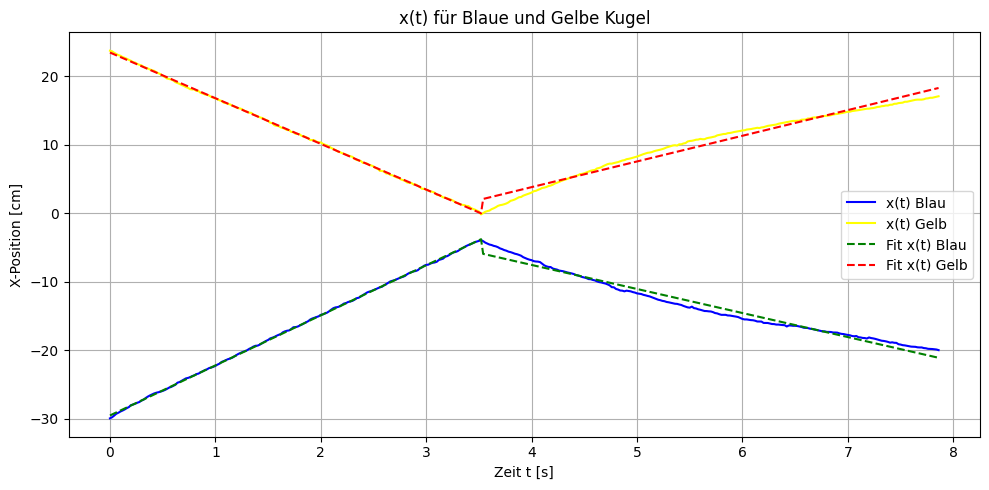

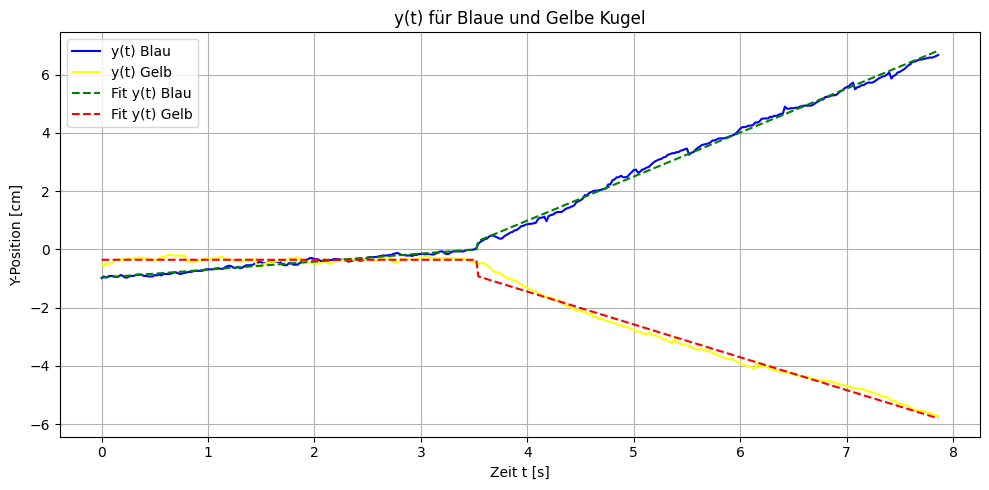

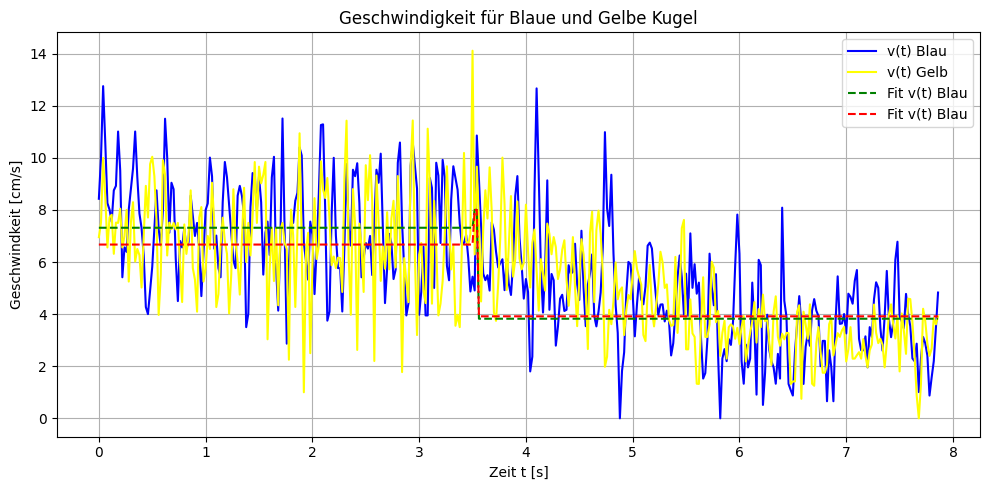

Durchschnittliche Geschwindigkeiten vor und nach dem Stoß:
Blaue Kugel:
Vor dem Stoß: 7.46 cm/s
Nach dem Stoß: 4.36 cm/s
Gelbe Kugel:
Vor dem Stoß: 6.89 cm/s
Nach dem Stoß: 4.28 cm/s


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import os

# Zeitpunkte definieren
stosszeit = 3.52

# Daten Position definieren
Daten_x_Blau = []
Daten_y_Blau = []
Daten_x_Gelb = []
Daten_y_Gelb = []
Daten_t = []

# Daten Fit Position definieren
Fit_x_Blau = []
Fit_x_Gelb = []
Fit_y_Blau = []
Fit_y_Gelb = []

# Daten Geschwindigkeiten definieren
Daten_v_Blau = []
Daten_v_Gelb = []

# Daten Fit Geschwindigkeiten definieren
Fit_v_Blau = []
Fit_v_Gelb = []

# Ordnerpfad anpassen
filepath = "Aufgabe_1_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]

for file in csv_files:
    color = file[5:9]
    df = pd.read_csv(os.path.join(filepath, file), usecols=[0, 1, 2])  # nur t, x, y
    df.columns = ['t', 'x', 'y']

    #Daten definieren
    globals()[f'Daten_x_{color}'] = df['x'].values
    globals()[f'Daten_y_{color}'] = df['y'].values
    globals()[f'Daten_t'] = df['t'].values

    # Daten vor und nach Stoß
    df_vor = df[df['t'] <= stosszeit]
    df_nach = df[df['t'] > stosszeit]

    #Positionen Fits finden X
    fit_vor_Stoss_x = np.polyfit(df_vor['t'], df_vor['x'], 1)
    fit_nach_Stoss_x = np.polyfit(df_nach['t'], df_nach['x'], 1)
    fit_vor_Stoss_x = np.array(fit_vor_Stoss_x)
    fit_nach_Stoss_x = np.array(fit_nach_Stoss_x)
    globals()[f'Fit_x_{color}'] = np.piecewise(
        df['t'].values,
        [df['t'].values <= stosszeit, df['t'].values > stosszeit],
        [lambda t: fit_vor_Stoss_x[0] * t + fit_vor_Stoss_x[1],
         lambda t: fit_nach_Stoss_x[0] * t + fit_nach_Stoss_x[1]]
    )

    #Positionen Fits finden Y
    fit_vor_Stoss_y = np.polyfit(df_vor['t'], df_vor['y'], 1)
    fit_nach_Stoss_y = np.polyfit(df_nach['t'], df_nach['y'], 1)
    fit_vor_Stoss_y = np.array(fit_vor_Stoss_y)
    fit_nach_Stoss_y = np.array(fit_nach_Stoss_y)
    globals()[f'Fit_y_{color}'] = np.piecewise(
        df['t'].values,
        [df['t'].values <= stosszeit, df['t'].values > stosszeit],
        [lambda t: fit_vor_Stoss_y[0] * t + fit_vor_Stoss_y[1],
         lambda t: fit_nach_Stoss_y[0] * t + fit_nach_Stoss_y[1]]
    )


    # Geschwindigkeiten finden
    v_x = np.gradient(df['x'], df['t'])
    v_y = np.gradient(df['y'], df['t'])
    v = np.sqrt(v_x**2 + v_y**2)
    globals()[f'Daten_v_{color}'] = v

    # Fit Geschwindigkeiten finden
    v_fit_x = np.gradient(globals()[f'Fit_x_{color}'], df['t'])
    v_fit_y = np.gradient(globals()[f'Fit_y_{color}'], df['t'])
    v_fit_with_max = np.sqrt(v_fit_x**2 + v_fit_y**2)
    v_fit = np.clip(v_fit_with_max, -20, 8)
    globals()[f'Fit_v_{color}'] = v_fit
    


# Plot X(t) Blau und Gelb
plt.figure(figsize=(10, 5))
plt.plot(Daten_t, Daten_x_Blau, label='x(t) Blau', color='blue')
plt.plot(Daten_t, Daten_x_Gelb, label='x(t) Gelb', color='yellow')
plt.plot(Daten_t, Fit_x_Blau, label='Fit x(t) Blau', color='green', linestyle='--')
plt.plot(Daten_t, Fit_x_Gelb, label='Fit x(t) Gelb', color='red', linestyle='--')
plt.xlabel('Zeit t [s]')
plt.ylabel('X-Position [cm]')
plt.title('x(t) für Blaue und Gelbe Kugel')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#Plot Y(t) Blau und Gelb
plt.figure(figsize=(10, 5))
plt.plot(Daten_t, Daten_y_Blau, label='y(t) Blau', color='blue')
plt.plot(Daten_t, Daten_y_Gelb, label='y(t) Gelb', color='yellow')
plt.plot(Daten_t, Fit_y_Blau, label='Fit y(t) Blau', color='green', linestyle='--')
plt.plot(Daten_t, Fit_y_Gelb, label='Fit y(t) Gelb', color='red', linestyle='--')
plt.xlabel('Zeit t [s]')
plt.ylabel('Y-Position [cm]')
plt.title('y(t) für Blaue und Gelbe Kugel')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
    

#Geschwindigkeiten X(t) Blau und Gelb
plt.figure(figsize=(10, 5))
plt.plot(Daten_t, Daten_v_Blau, label='v(t) Blau', color='blue')
plt.plot(Daten_t, Daten_v_Gelb, label='v(t) Gelb', color='yellow')
plt.plot(Daten_t, Fit_v_Blau, label='Fit v(t) Blau', color='green', linestyle='--')
plt.plot(Daten_t, Fit_v_Gelb, label='Fit v(t) Blau', color='red', linestyle='--')
plt.xlabel('Zeit t [s]')
plt.ylabel('Geschwindkeit [cm/s]')
plt.title('Geschwindigkeit für Blaue und Gelbe Kugel')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Durchschnittliche Geschwindigkeiten vor und nach dem Stoß:")
print("Blaue Kugel:")
print(f"Vor dem Stoß: {np.mean(Daten_v_Blau[Daten_t <= stosszeit]):.2f} cm/s")
print(f"Nach dem Stoß: {np.mean(Daten_v_Blau[Daten_t > stosszeit]):.2f} cm/s")
print("Gelbe Kugel:")
print(f"Vor dem Stoß: {np.mean(Daten_v_Gelb[Daten_t <= stosszeit]):.2f} cm/s")
print(f"Nach dem Stoß: {np.mean(Daten_v_Gelb[Daten_t > stosszeit]):.2f} cm/s")


